![OneHealth DataSpace](https://bigdata.dataspace.cesga.es/static/images/public/imagotipo.png)

> **⚠️ ADVERTENCIA**: actualmente la plataforma está en fase de pueba. Agradecemos que nos hagáis llegar cualquier comentario a onehealth@cesga.es.

# Visualizando datos

Para empezar, importaremos algunos módulos que en general nos serán de utilidad:

In [21]:
import onehealth
import pyspark.sql.functions as F
from pyspark.sql.functions import col, expr
import numpy as np
import pandas as pd

Una vez analizados y procesados los datos, podemos representarlos para visualizarlos de una manera más sencilla.

Para ello, podemos utilizar varias librerías, entre las que destacan Bokeh y Matplotlib.

In [22]:
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.io import output_notebook
from bokeh.models.formatters import DatetimeTickFormatter
from bokeh.models.tools import HoverTool

### Ejemplo 1: Captura del Bacalao del Atlántico

Probaremos a representar los datos de captura del bacalao del Atlántico.

Lo primero será filtrar los datos para quedarnos únicamente con los datos de captura de la especie que nos interesa.

In [23]:
capturas = onehealth.load("especies/ieo_capturas")
bacalao = capturas.filter(col('spanish_fao_name') == 'Bacalao del Atlántico')
bacalao = bacalao.toPandas()

Creamos la gráfica, en este caso con Matplotlib.

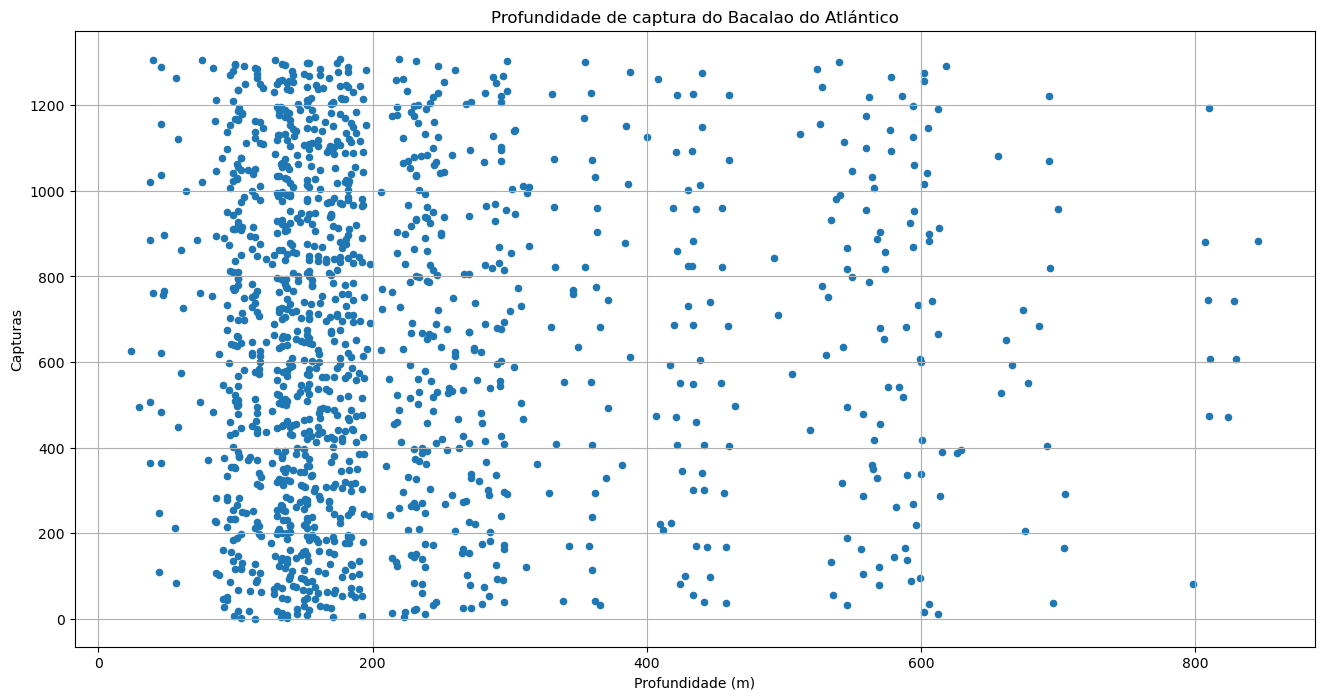

In [ ]:
plt.figure(figsize=(16, 8))
plt.scatter(bacalao['depth'].astype(float), bacalao.index, marker='o', s=20)
plt.xlabel('Profundidad (m)')
plt.ylabel('Capturas')
plt.title('Profundidad de la captura del Bacalao del Atlántico')
plt.grid(True)
plt.show()

En este caso, podemos ver los datos de la captura del bacalao en relación con la cantidad capturada y la profundidad (en metros) a la que se realizó la captura.

Veamos otro ejemplo. En este caso vamos a representar en un mapa el índice de afloramiento.

### Ejemplo 2: Mapa del índice de afloramiento.

Cargamos y realizamos un ligero tratamiento de los datos.

In [33]:
afloramiento = onehealth.load("afloramento/intecmar_hfrui")
afloramiento_pd = afloramiento.toPandas()
afloramiento_pd['TIME'] = pd.to_datetime(afloramiento_pd['TIME'])
afloramiento_pd['UI'] = afloramiento_pd['UI'].astype(float)

print(afloramiento_pd.head())

        TIME DEPTH           LATITUDE           LONGITUDE DEPH crs          UI
0 2022-03-20     0   40.7329216003418  -9.283395767211914  0.0   0 -614.110350
1 2022-03-20     0  40.78694915771485  -9.283395767211914  0.0   0 -613.438900
2 2022-03-20     0  40.78694915771485  -9.210384368896484  0.0   0  -22.431360
3 2022-03-20     0  40.84098052978516  -9.283395767211914  0.0   0 -861.476440
4 2022-03-20     0  40.84098052978516  -9.210384368896484  0.0   0 -118.581116


Convertimos los datos al formato Web Mercator para mostrarlos en un mapa CartoDB Positron.

In [34]:
from pyproj import Transformer

in_proj = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
afloramiento_pd["LONGITUDE_MERCATOR"], afloramiento_pd["LATITUDE_MERCATOR"] = in_proj.transform(afloramiento_pd["LONGITUDE"].values, afloramiento_pd["LATITUDE"].values)
afloramiento_pd = afloramiento_pd[['TIME', 'LONGITUDE_MERCATOR', 'LATITUDE_MERCATOR', 'UI']]
afloramiento_pd = afloramiento_pd.groupby(["LONGITUDE_MERCATOR", "LATITUDE_MERCATOR"])["UI"].agg("mean").reset_index()
print(afloramiento_pd.head())

afloramiento_source = ColumnDataSource(data=afloramiento_pd)

   LONGITUDE_MERCATOR  LATITUDE_MERCATOR          UI
0       -1.065933e+06       5.304022e+06 -374.157371
1       -1.065933e+06       5.320463e+06 -407.620304
2       -1.065933e+06       5.328695e+06 -474.549121
3       -1.057806e+06       5.263041e+06 -268.244514
4       -1.057806e+06       5.271223e+06 -311.085682


Representamos los datos en el mapa interactivo.

In [ ]:
from bokeh.io import output_notebook, show
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, ColorBar, HoverTool
from bokeh.tile_providers import get_provider, Vendors
from bokeh.transform import linear_cmap, transform

tile_provider = get_provider(Vendors.CARTODBPOSITRON)
 
tooltips = [("UI", "@UI")]
m = figure(
    title='Mapa del índice de afloramiento',
    width=850,
    height=700,
    x_range=(-1500000, -700000),
    y_range=(5000000, 5500000),
    x_axis_type='mercator',
    y_axis_type='mercator',
    tooltips=tooltips,
    tools='hover,crosshair,pan,wheel_zoom,zoom_in,zoom_out,box_zoom,undo,redo,reset,tap,save,box_select,poly_select,lasso_select'
)

palette = ['#d7191c', '#fdae61', '#a6d96a', '#1a9641']
mapper = linear_cmap(field_name='UI', palette=palette, low=min(afloramiento_pd['UI']), high=max(afloramiento_pd['UI']))
m.add_tile(tile_provider)
m.circle(
    x="LONGITUDE_MERCATOR",
    y="LATITUDE_MERCATOR",
    size=3,
    color=mapper,
    source=afloramiento_source
)


color_bar = ColorBar(color_mapper=mapper['transform'], width=10, location=(0,0))
m.add_layout(color_bar, 'right')

output_notebook()
show(m)

Loading BokehJS ...